# Édition sémantique dans l'espace latent $\mathcal{W}^+$

Ce notebook illustre l'**édition d'attributs faciaux** dans l'espace latent $\mathcal{W}^+$ de StyleGAN2.

## Principe

Un classifieur d'attributs (lunettes, genre, âge) est entraîné sur des visages synthétiques. On cherche ensuite la **frontière SVM** séparant les deux classes dans $\mathcal{W}^+$. La normale à cette frontière définit la direction de l'attribut.

$$w_{\text{édité}} = w + \alpha \cdot n$$

## Initialisation

In [2]:
import sys
import pickle
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().resolve().parent

STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
for p in [str(PROJECT_DIR), str(STYLEGAN2_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from stylegan2.torch_utils.misc import get_device

SEED = 42
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

MODELS_DIR = PROJECT_DIR / 'models'

device = get_device()
print(f"Device: {device}")

Device: mps


## Chargement de StyleGAN2

In [3]:
with open(MODELS_DIR / 'ffhq.pkl', 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)
G = G.eval().requires_grad_(False)

In [5]:
@dataclass
class Boundary:
    normal: torch.Tensor
    intercept: torch.Tensor


def image_to_display(img: torch.Tensor) -> np.ndarray:
    """Convert [-1,1] or [0,1] tensor to HWC numpy for imshow (NumPy 2.x safe)."""
    if img.min() < 0.0:
        img = (img + 1.0) / 2.0
    img = img.clamp(0.0, 1.0).permute(1, 2, 0).cpu().float()
    return np.array(img.tolist(), dtype=np.float32)


def sample_directions(
    normals: list[torch.Tensor],
    alphas: list[float] = [-6.0, -4.0, -2.0, 0.0, 2.0, 4.0, 6.0],
    n_samples: int = 4,
    labels: list[str] | None = None,
) -> None:
    """Visualise the effect of traversing each semantic direction.

    Rows: one random face per sample, repeated for each normal.
    Columns: alpha values.
    """
    n_rows = len(normals) * n_samples
    fig = plt.figure(figsize=(2 * len(alphas), 2 * n_rows))
    for i in range(n_samples):
        z = torch.randn([1, G.z_dim], generator=torch.Generator().manual_seed(SEED + i)).to(device)
        w = G.mapping(z, None)
        for k, n in enumerate(normals):
            for j, alpha in enumerate(alphas):
                w_edit = w + alpha * n
                with torch.inference_mode():
                    img = G.synthesis(w_edit, noise_mode='const')[0]
                ax = fig.add_subplot(n_rows, len(alphas), (len(normals) * i + k) * len(alphas) + j + 1)
                if i == 0:
                    label = labels[k] if labels else ""
                    title = f"α={alpha:+.0f}" + (f"\n{label}" if label and j == len(alphas) // 2 else "")
                    ax.set_title(title, fontsize=7)
                ax.imshow(image_to_display(img))
                ax.set_axis_off()
    fig.tight_layout()
    plt.show()

## Chargement des frontières pré-calculées

Les frontières ont été obtenues en :
1. Générant 65 536 visages synthétiques avec StyleGAN2
2. Classifiant chacun avec un réseau ResNet entraîné sur les attributs CelebA
3. Sélectionnant les 2 048 exemples les plus "clairs" de chaque classe (ie. score le plus faible ou plus élevé)
4. Entraînant un SVM linéaire dans $\mathcal{W}^+$
5. Normalisant le vecteur coefficient pour obtenir la normale unitaire

In [ ]:
eyeglass_boundary = torch.load(MODELS_DIR / 'eyeglass_boundary.npz', map_location=device, weights_only=False)
age_boundary      = torch.load(MODELS_DIR / 'young_boundary.npz',    map_location=device, weights_only=False)

n_eyeglass = eyeglass_boundary.normal  # alpha > 0 -> with glasses
n_age      = age_boundary.normal       # alpha > 0 -> older

## Direction "lunettes"

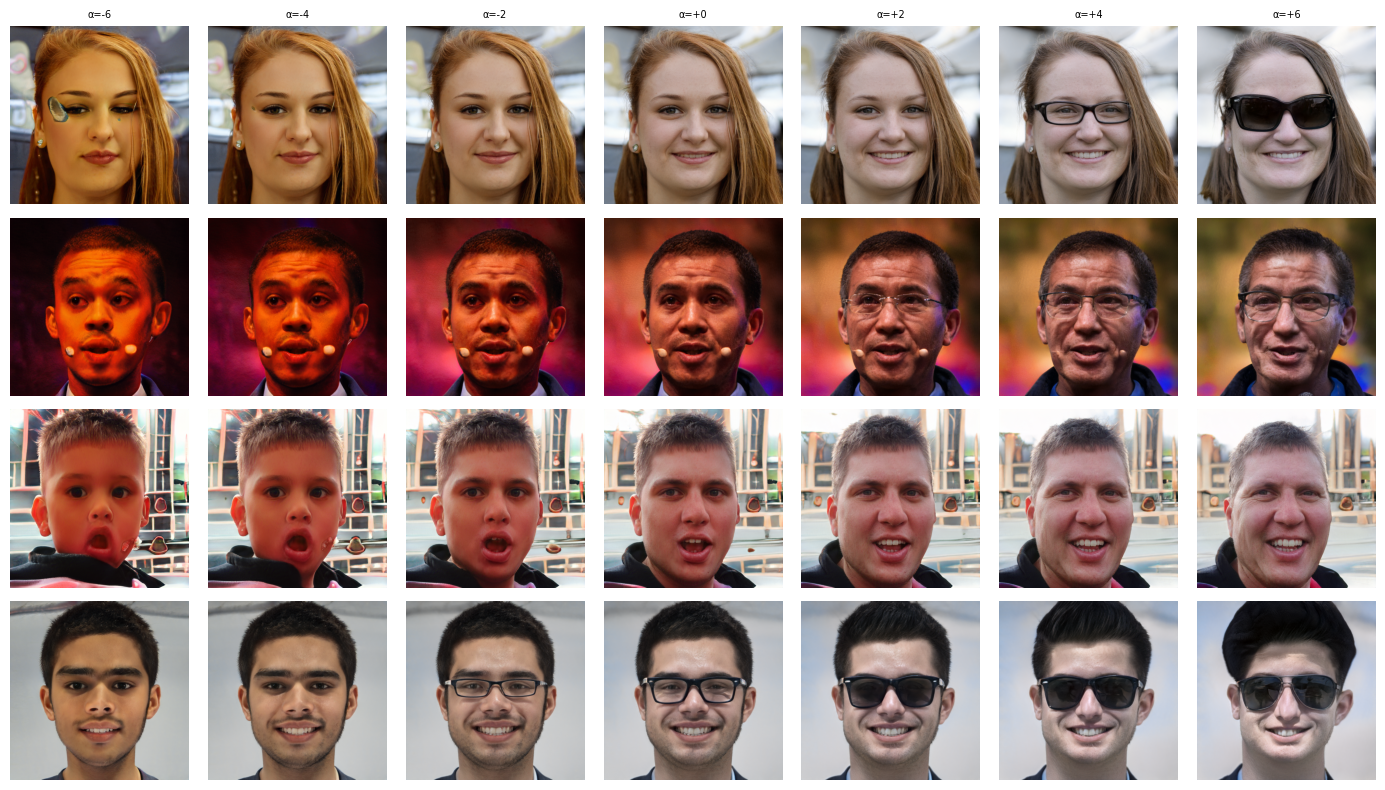

In [5]:
sample_directions([n_eyeglass])

## Direction "âge"

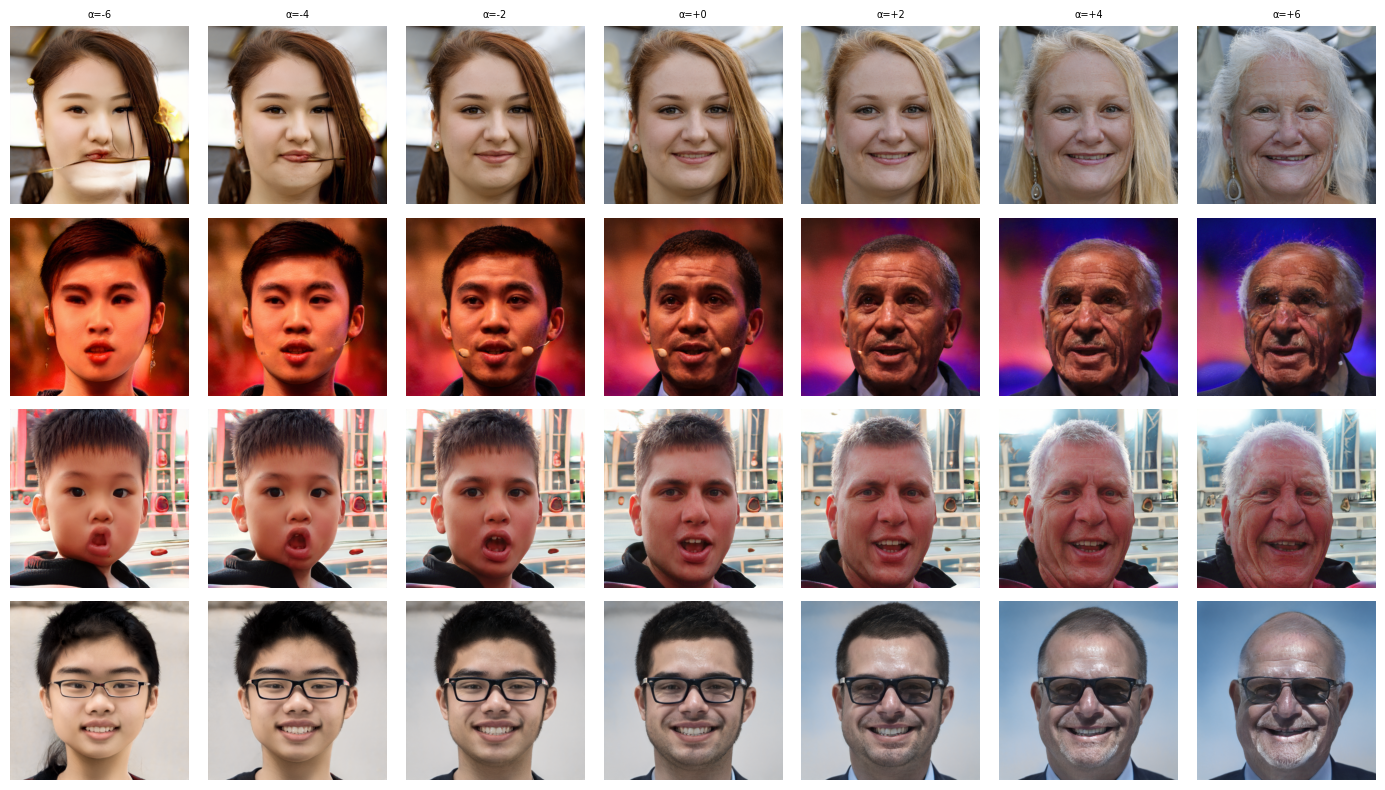

In [6]:
sample_directions([n_age])

## Direction "lunettes" orthogonale à l'âge

La normale brute $n_1$ (lunettes) est corrélée avec $n_2$ (âge). On applique la projection donnée dans InterFaceGAN pour supprimer cette corrélation :

$$n_\perp = n_1 - (n_1 \cdot n_2)\, n_2, \qquad \hat{n}_\perp = \frac{n_\perp}{\|n_\perp\|}$$

La direction $\hat{n}_\perp$ ajoute ou retire les lunettes en modifiant moins l'âge.

In [11]:
dot = torch.inner(n_eyeglass[0, 0], n_age[0, 0]).item()
print(f"dot(n_eyeglass, n_age) = {dot}")

n_eyeglass_ortho = n_eyeglass - dot * n_age
n_eyeglass_ortho = n_eyeglass_ortho / torch.norm(n_eyeglass_ortho[0, 0])

dot_after = torch.inner(n_eyeglass_ortho[0, 0], n_age[0, 0]).item()
print(f"dot(n_eyeglass_ortho, n_age) = {dot_after}")

dot(n_eyeglass, n_age) = 0.2542021572589874
dot(n_eyeglass_ortho, n_age) = -7.450580596923828e-09


### Comparaison : direction brute vs. orthogonale

Lignes impaires : $n_1$ (lunettes brut) \
Lignes paires : $\hat{n}_\perp$ (lunettes sans effet d'âge)

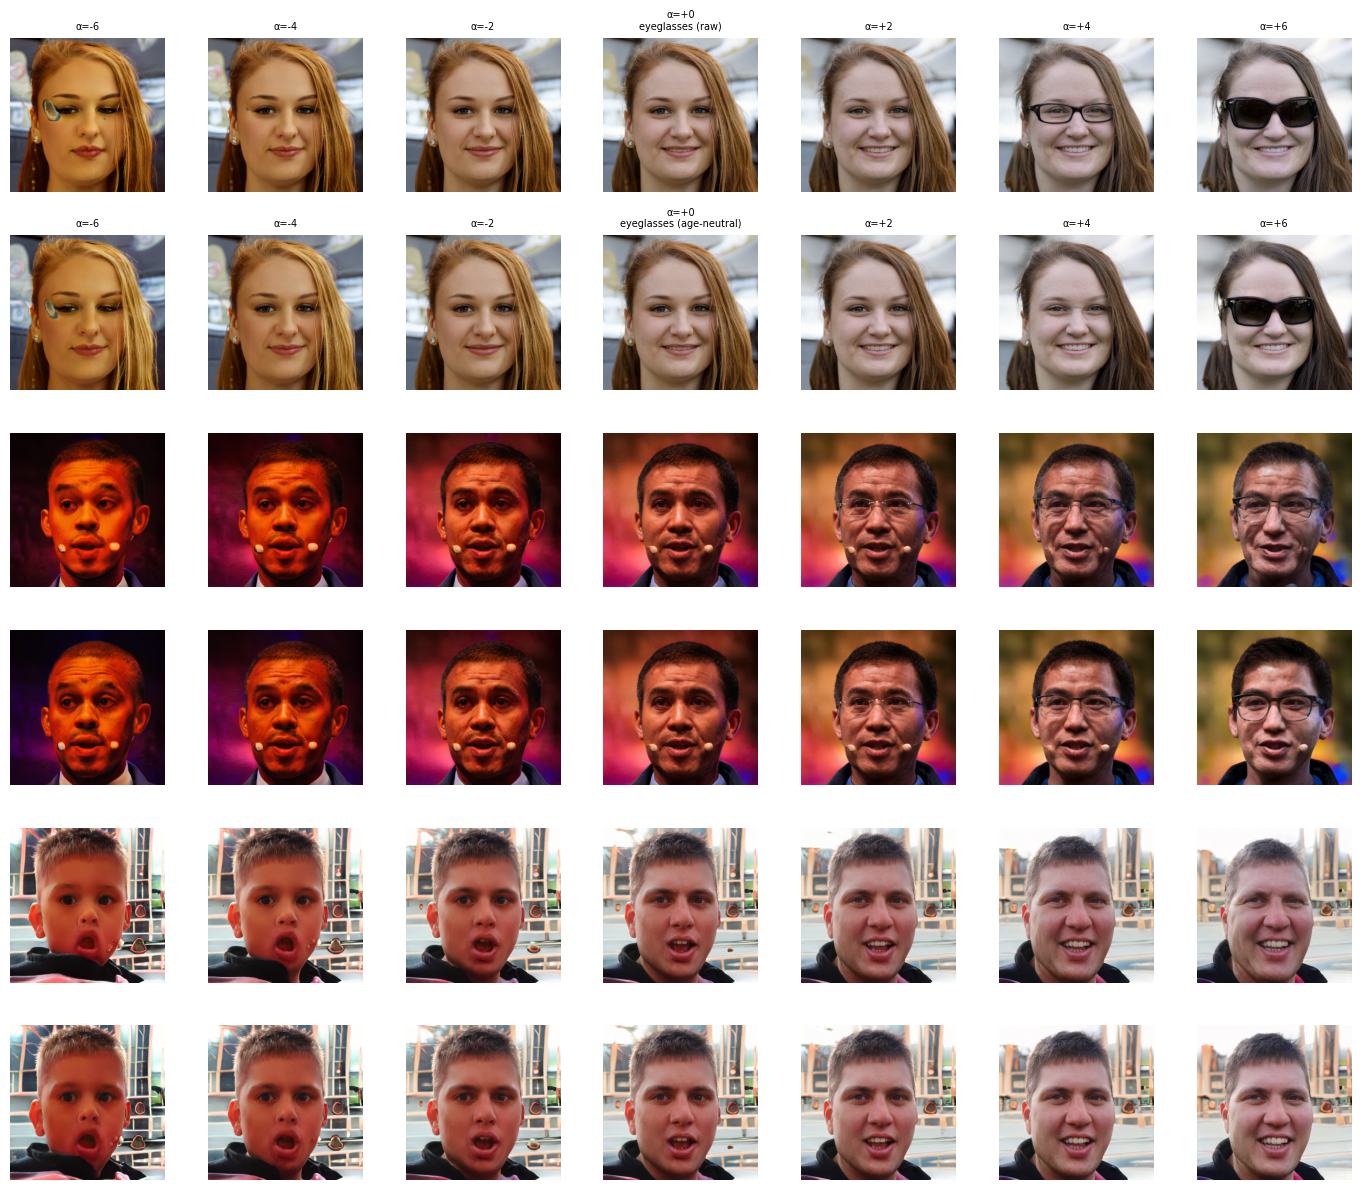

In [8]:
sample_directions(
    [n_eyeglass, n_eyeglass_ortho],
    n_samples=3,
    labels=["eyeglasses (raw)", "eyeglasses (age-neutral)"],
)